
# Amazon Product Sales Analysis 📊

## Project Overview
This project analyzes Amazon product sales data using Python and Pandas.  
The goal is to uncover business insights, identify trends, and practice real-world data analysis techniques.

---

## Tools & Libraries Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## Skills Demonstrated
✔ Data Cleaning  
✔ Handling Missing Values  
✔ Exploratory Data Analysis (EDA)  
✔ Data Visualization  
✔ Business Insights Generation


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")


Libraries imported successfully.



## Load Dataset
Replace the file path below with your dataset location.


In [2]:
df = pd.read_csv(r"C:\Users\NISCHIT PC\Downloads\amazon_products_sales_data_cleaned.csv")

print("Dataset Loaded Successfully")
df.head()


Dataset Loaded Successfully


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00



## Dataset Overview
Understanding the structure of the dataset.


In [3]:

print("Shape of Dataset:", df.shape)
print("\nDataset Information:\n")
df.info()


Shape of Dataset: (42675, 17)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at

In [4]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
product_rating,41651.0,4.399431,0.386997,1.00,4.20,4.50,4.70,5.00
total_reviews,41651.0,3087.106000,13030.460133,1.00,82.00,343.00,1886.00,865598.00
purchased_last_month,32164.0,1293.665278,6318.323574,50.00,100.00,200.00,400.00,100000.00
discounted_price,40613.0,243.227289,473.351545,2.16,29.69,84.99,224.00,5449.00
original_price,40613.0,257.611107,496.633495,2.16,32.99,89.00,229.99,5449.00
discount_percentage,40613.0,6.547151,12.744715,0.00,0.00,0.00,8.49,85.42



## Missing Value Analysis
Checking and handling missing values.


In [5]:

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)


,Missing Values,Missing Percentage
sustainability_tags,39267,92.014060
buy_box_availability,14653,34.336262
delivery_date,11983,28.079672
purchased_last_month,10511,24.630346
product_page_url,2069,4.848272
original_price,2062,4.831869
discounted_price,2062,4.831869
discount_percentage,2062,4.831869
total_reviews,1024,2.399531
product_rating,1024,2.399531


In [6]:

# Fill numerical missing values with median
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(exclude='number').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully.")


Missing values handled successfully.



## Duplicate Records


In [7]:

print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0



## Data Type Conversion


In [8]:

df['total_reviews'] = df['total_reviews'].astype(int)
df['purchased_last_month'] = df['purchased_last_month'].astype(int)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        42675 non-null  float64
 2   total_reviews         42675 non-null  int64  
 3   purchased_last_month  42675 non-null  int64  
 4   discounted_price      42675 non-null  float64
 5   original_price        42675 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  42675 non-null  object 
 10  delivery_date         42675 non-null  object 
 11  sustainability_tags   42675 non-null  object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      42675 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   


# Exploratory Data Analysis 📈


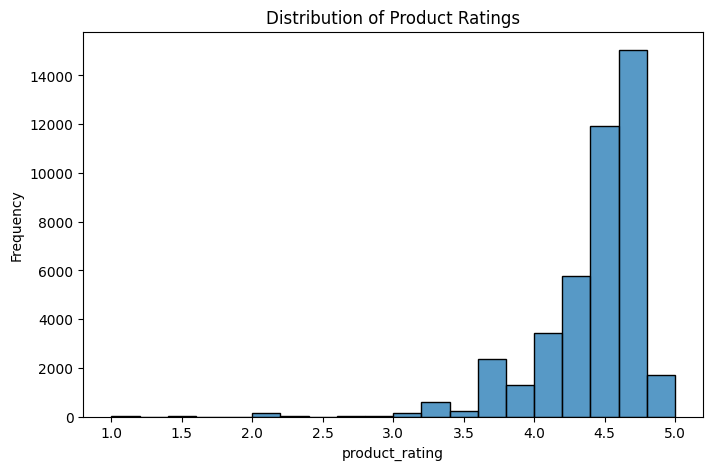

In [10]:

# Distribution of Product Ratings

plt.figure(figsize=(8,5))
sns.histplot(df['product_rating'], bins=20)

plt.title('Distribution of Product Ratings')
plt.xlabel('product_rating')
plt.ylabel('Frequency')

plt.show()


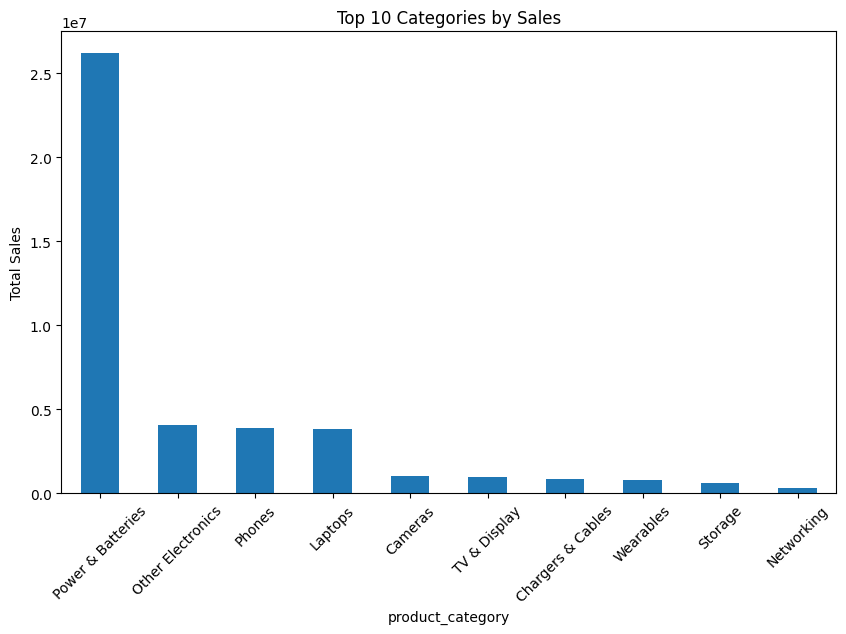

In [16]:

# Top 10 Product Categories by Sales

top_categories = df.groupby('product_category')['purchased_last_month'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_categories.plot(kind='bar')

plt.title('Top 10 Categories by Sales')
plt.xlabel('product_category')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()


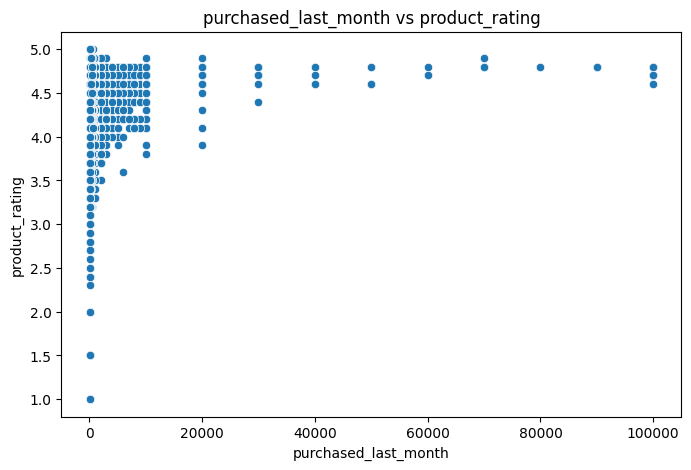

In [18]:

# Price vs Rating Analysis

plt.figure(figsize=(8,5))
sns.scatterplot(x='purchased_last_month', y='product_rating', data=df)

plt.title('purchased_last_month vs product_rating')
plt.xlabel('purchased_last_month')
plt.ylabel('product_rating')

plt.show()


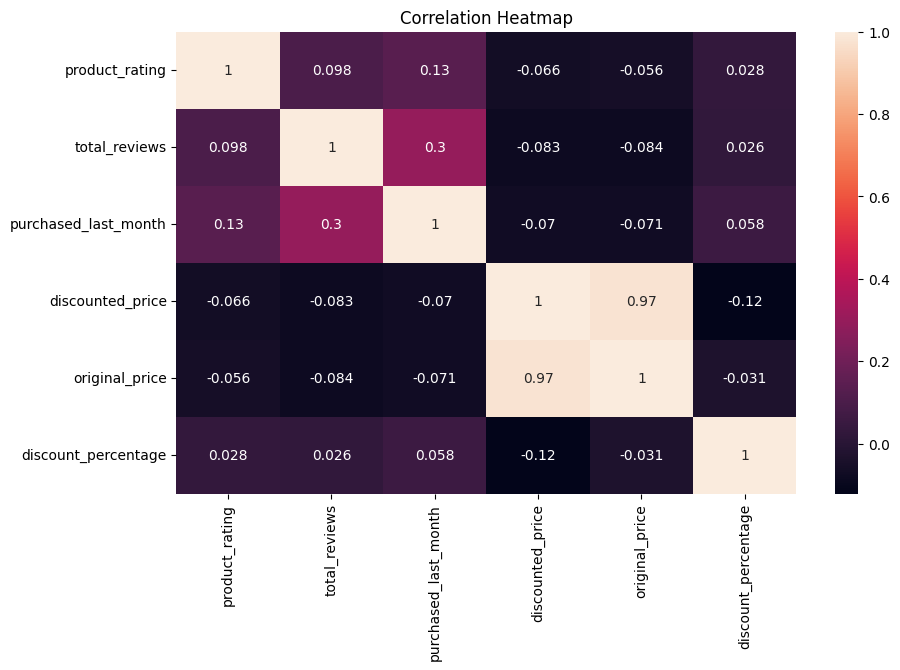

In [19]:

# Correlation Heatmap

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)

plt.title('Correlation Heatmap')

plt.show()



# Key Business Insights 💡

### Insights from the Analysis
- Products with higher ratings generally receive better engagement.
- Certain categories contribute significantly more to overall sales.
- Price does not always directly impact product ratings.
- Customer reviews can help identify product popularity and trust.

---

## Conclusion
This project demonstrates practical data analysis skills using Python and Pandas.  
It also highlights the importance of data-driven decision-making in e-commerce businesses.
